# Project VI - Small-Scale Monte Carlo Uncertainty Propagation Prototype

This notebook implements the first Project VI Monte Carlo prototype for exactly two `validation_priority_A` candidates. It runs only `measured_only_parallax`: parallax is sampled from the catalog central value and measured-derived parallax uncertainty; RA, Dec, proper motion, and radial velocity are held fixed. This is not full Gaia astrometric covariance propagation.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactocentric
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA = ROOT / "data" / "processed"
FIG = ROOT / "figures"
REPORT = ROOT / "report"
FIG.mkdir(exist_ok=True)
REPORT.mkdir(exist_ok=True)

TARGET_IDS = ["3089847099636770560", "3089534353001157632"]
MC_MODE = "measured_only_parallax"
N_DRAWS = 200
RNG_SEED = 20260803

OUT_CANDIDATES = DATA / "project_vi_mc_prototype_candidate_uncertainties.csv"
OUT_DRAWS = DATA / "project_vi_mc_prototype_draw_summary.csv"
OUT_REPORT = REPORT / "project_vi_small_scale_mc_uncertainty_prototype.md"
FIG_ORBIT = FIG / "project_vi_mc_prototype_orbit_uncertainty.png"
FIG_L = FIG / "project_vi_mc_prototype_lz_lperp_uncertainty.png"

print("Project root:", ROOT)
print("Targets:", TARGET_IDS)
print("Mode:", MC_MODE, "draws per target:", N_DRAWS, "seed:", RNG_SEED)

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/liors/Documents/research/gaia-lamost-galactic-archaeology
Targets: ['3089847099636770560', '3089534353001157632']
Mode: measured_only_parallax draws per target: 200 seed: 20260803


In [2]:
def source_key(s):
    return pd.Series(s).astype("string").str.replace(r"\.0$", "", regex=True)

priority = pd.read_csv(DATA / "project_vi_validation_priority_candidates.csv", dtype={"source_id": "string"})
velocity = pd.read_csv(DATA / "gaia_lamost_larger_velocity_features.csv", dtype={"source_id": "string"})
reference = pd.read_csv(DATA / "project_ii_galpy_orbit_candidates.csv", dtype={"source_id": "string"})

for df in [priority, velocity, reference]:
    df["source_id_key"] = source_key(df["source_id"])

priority_targets = priority[priority["source_id_key"].isin(TARGET_IDS)].copy()
assert set(priority_targets["source_id_key"]) == set(TARGET_IDS), "Missing target in Project VI priority table"
assert (priority_targets["project_vi_validation_priority"] == "validation_priority_A").all(), "Target is not Project VI priority A"

velocity_cols = [
    "source_id_key", "ra_gaia", "dec_gaia", "parallax", "parallax_over_error",
    "pmra", "pmdec", "distance_pc", "rv", "ruwe", "coord_match_sep_arcsec",
]
reference_cols = [
    "source_id_key", "Lz_kpc_kms", "Lperp_kpc_kms", "Ltot_kpc_kms",
    "galpy_eccentricity", "galpy_rperi_kpc", "galpy_rap_kpc", "galpy_zmax_kpc",
    "galpy_energy", "galpy_ro_kpc", "galpy_vo_kms", "galpy_integration_time_gyr",
    "galpy_n_steps", "galpy_potential", "distance_quality_flag", "distance_recovery_source",
]

targets = (
    priority_targets
    .merge(velocity[velocity_cols], on="source_id_key", how="left", validate="one_to_one")
    .merge(reference[reference_cols], on="source_id_key", how="left", validate="one_to_one", suffixes=("", "_reference"))
)

num_cols = ["ra_gaia", "dec_gaia", "parallax", "parallax_over_error", "pmra", "pmdec", "distance_pc", "rv"]
for col in num_cols:
    targets[col] = pd.to_numeric(targets[col], errors="coerce")

targets["parallax_error"] = targets["parallax"] / targets["parallax_over_error"]
targets["distance_kpc_reference"] = targets["distance_pc"] / 1000.0
required = ["ra_gaia", "dec_gaia", "parallax", "parallax_over_error", "parallax_error", "pmra", "pmdec", "rv", "distance_kpc_reference"]
assert targets[required].notna().all().all(), "Missing required prototype input"

display_cols = ["source_id_key", "project_vi_validation_priority", "project_iii_priority_tier", "parallax", "parallax_over_error", "parallax_error", "pmra", "pmdec", "rv", "distance_pc", "distance_quality_flag"]
targets[display_cols]

,source_id_key,project_vi_validation_priority,project_iii_priority_tier,parallax,parallax_over_error,parallax_error,pmra,pmdec,rv,distance_pc,distance_quality_flag
0,3089847099636770560,validation_priority_A,priority_A,0.637151,26.753075,0.023816,-42.072760,-36.356421,-11.29,1569.487021,missing_parallax
1,3089534353001157632,validation_priority_A,priority_A,0.458766,25.166069,0.018230,2.906364,-36.283028,-43.26,2179.762224,missing_parallax


In [3]:
def compute_angular_momentum(ra_deg, dec_deg, distance_kpc, pmra_masyr, pmdec_masyr, rv_kms):
    coord = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        distance=distance_kpc * u.kpc,
        pm_ra_cosdec=pmra_masyr * u.mas / u.yr,
        pm_dec=pmdec_masyr * u.mas / u.yr,
        radial_velocity=rv_kms * u.km / u.s,
        frame="icrs",
    )
    galcen = coord.transform_to(Galactocentric()).cartesian
    diff = galcen.differentials[next(iter(galcen.differentials.keys()))]

    x = galcen.x.to_value(u.kpc)
    y = galcen.y.to_value(u.kpc)
    z = galcen.z.to_value(u.kpc)
    vx = diff.d_x.to_value(u.km / u.s)
    vy = diff.d_y.to_value(u.km / u.s)
    vz = diff.d_z.to_value(u.km / u.s)

    Lx = y * vz - z * vy
    Ly = z * vx - x * vz
    Lz = x * vy - y * vx
    Lperp = np.sqrt(Lx**2 + Ly**2)
    Ltot = np.sqrt(Lx**2 + Ly**2 + Lz**2)
    return {
        "Lx_kpc_kms": float(Lx),
        "Ly_kpc_kms": float(Ly),
        "Lz_kpc_kms": float(Lz),
        "Lperp_kpc_kms": float(Lperp),
        "Ltot_kpc_kms": float(Ltot),
    }


def integrate_orbit(ra_deg, dec_deg, distance_kpc, pmra_masyr, pmdec_masyr, rv_kms):
    orbit = Orbit(
        vxvv=[ra_deg, dec_deg, distance_kpc, pmra_masyr, pmdec_masyr, rv_kms],
        radec=True,
        ro=8.2,
        vo=232.0,
        solarmotion="schoenrich",
    )
    ts = np.linspace(0, 5, 1001) * u.Gyr
    orbit.integrate(ts, MWPotential2014)
    return {
        "galpy_eccentricity": float(orbit.e()),
        "galpy_rperi_kpc": float(orbit.rperi()),
        "galpy_rap_kpc": float(orbit.rap()),
        "galpy_zmax_kpc": float(orbit.zmax()),
        "galpy_energy": float(orbit.E()),
    }

central_rows = []
for row in targets.itertuples(index=False):
    central = {"source_id": row.source_id_key}
    central.update(compute_angular_momentum(row.ra_gaia, row.dec_gaia, row.distance_kpc_reference, row.pmra, row.pmdec, row.rv))
    central.update(integrate_orbit(row.ra_gaia, row.dec_gaia, row.distance_kpc_reference, row.pmra, row.pmdec, row.rv))
    central_rows.append(central)

central_recomputed = pd.DataFrame(central_rows)
central_recomputed

,source_id,Lx_kpc_kms,Ly_kpc_kms,Lz_kpc_kms,Lperp_kpc_kms,Ltot_kpc_kms,galpy_eccentricity,galpy_rperi_kpc,galpy_rap_kpc,galpy_zmax_kpc,galpy_energy
0,3089847099636770560,319.447328,-3516.983909,-961.155555,3531.461796,3659.923826,0.708753,9.389509,55.088452,52.847640,11032.924217
1,3089534353001157632,221.031601,-1285.033821,471.066843,1303.904479,1386.387702,0.836985,1.943723,21.903518,17.784401,-24499.048819


In [4]:
rng = np.random.default_rng(RNG_SEED)
draw_rows = []

for row in targets.itertuples(index=False):
    parallax_draws = rng.normal(float(row.parallax), float(row.parallax_error), N_DRAWS)
    for draw_index, parallax_draw in enumerate(parallax_draws):
        base = {
            "source_id": row.source_id_key,
            "mc_mode": MC_MODE,
            "draw_index": draw_index,
            "parallax_draw_mas": float(parallax_draw),
            "parallax_reference_mas": float(row.parallax),
            "parallax_error_mas": float(row.parallax_error),
            "pmra_masyr_fixed": float(row.pmra),
            "pmdec_masyr_fixed": float(row.pmdec),
            "radial_velocity_kms_fixed": float(row.rv),
            "valid_draw": False,
            "rejection_reason": "",
        }
        if parallax_draw <= 0:
            base["rejection_reason"] = "nonpositive_parallax"
            draw_rows.append(base)
            continue

        distance_kpc = 1.0 / float(parallax_draw)
        base["distance_kpc_draw"] = distance_kpc
        try:
            base.update(compute_angular_momentum(row.ra_gaia, row.dec_gaia, distance_kpc, row.pmra, row.pmdec, row.rv))
            base.update(integrate_orbit(row.ra_gaia, row.dec_gaia, distance_kpc, row.pmra, row.pmdec, row.rv))
            base["valid_draw"] = True
        except Exception as exc:
            base["rejection_reason"] = f"orbit_failure:{type(exc).__name__}"
        draw_rows.append(base)

draws = pd.DataFrame(draw_rows)
draws.to_csv(OUT_DRAWS, index=False)
print("Saved", OUT_DRAWS, draws.shape)
draws.groupby(["source_id", "valid_draw"], dropna=False).size().unstack(fill_value=0)

Saved /Users/liors/Documents/research/gaia-lamost-galactic-archaeology/data/processed/project_vi_mc_prototype_draw_summary.csv (400, 22)


valid_draw,True
source_id,
3089534353001157632,200
3089847099636770560,200


In [5]:
METRICS = {
    "Lz_kpc_kms": "Lz",
    "Lperp_kpc_kms": "Lperp",
    "Ltot_kpc_kms": "Ltot",
    "galpy_eccentricity": "eccentricity",
    "galpy_rperi_kpc": "rperi",
    "galpy_rap_kpc": "rap",
    "galpy_zmax_kpc": "Zmax",
}

summary_rows = []
for row in targets.itertuples(index=False):
    sid = row.source_id_key
    valid = draws[(draws["source_id"] == sid) & (draws["valid_draw"])]
    rejected = draws[(draws["source_id"] == sid) & (~draws["valid_draw"])]
    out = {
        "source_id": sid,
        "mc_mode": MC_MODE,
        "n_draws_requested": N_DRAWS,
        "n_draws_valid": int(len(valid)),
        "n_draws_rejected": int(len(rejected)),
        "n_draws_rejected_nonpositive_parallax": int((rejected.get("rejection_reason", pd.Series(dtype=str)) == "nonpositive_parallax").sum()),
        "success_fraction": float(len(valid) / N_DRAWS),
        "parallax": float(row.parallax),
        "parallax_over_error": float(row.parallax_over_error),
        "parallax_error": float(row.parallax_error),
        "parallax_uncertainty_provenance": "measured_derived_from_parallax_over_error",
        "distance_reference_kpc": float(row.distance_kpc_reference),
        "distance_method": "inverse_parallax_per_draw",
        "pmra": float(row.pmra),
        "pmdec": float(row.pmdec),
        "radial_velocity": float(row.rv),
        "pmra_uncertainty_provenance": "missing_uncertainty_fixed_in_draws",
        "pmdec_uncertainty_provenance": "missing_uncertainty_fixed_in_draws",
        "radial_velocity_uncertainty_provenance": "missing_uncertainty_fixed_in_draws",
        "distance_uncertainty_provenance": "derived_from_sampled_parallax_not_independently_sampled",
        "covariance_provenance": "missing_covariance_not_used",
        "assumed_uncertainty_used": False,
        "assumed_uncertainty_note": "not used",
        "distance_quality_flag_current_project_vi": row.distance_quality_flag,
        "distance_quality_semantics_note": "larger recovered table has parallax central value; full uncertainty/covariance inputs are missing",
    }

    reference_row = reference[reference["source_id_key"] == sid].iloc[0]
    central_row = central_recomputed[central_recomputed["source_id"] == sid].iloc[0]
    for metric, short in METRICS.items():
        ref_val = pd.to_numeric(reference_row[metric], errors="coerce") if metric in reference_row else np.nan
        central_val = pd.to_numeric(central_row[metric], errors="coerce") if metric in central_row else np.nan
        vals = pd.to_numeric(valid[metric], errors="coerce").dropna()
        p16, med, p84 = np.percentile(vals, [16, 50, 84])
        out[f"{short}_reference"] = float(ref_val)
        out[f"{short}_central_recomputed"] = float(central_val)
        out[f"{short}_mc_median"] = float(med)
        out[f"{short}_mc_p16"] = float(p16)
        out[f"{short}_mc_p84"] = float(p84)
        out[f"{short}_mc_lower_uncertainty"] = float(med - p16)
        out[f"{short}_mc_upper_uncertainty"] = float(p84 - med)
    summary_rows.append(out)

candidate_summary = pd.DataFrame(summary_rows)
candidate_summary.to_csv(OUT_CANDIDATES, index=False)
print("Saved", OUT_CANDIDATES, candidate_summary.shape)
candidate_summary[["source_id", "success_fraction", "Lz_mc_median", "Lz_mc_p16", "Lz_mc_p84", "eccentricity_mc_median", "eccentricity_mc_p16", "eccentricity_mc_p84"]]

Saved /Users/liors/Documents/research/gaia-lamost-galactic-archaeology/data/processed/project_vi_mc_prototype_candidate_uncertainties.csv (2, 74)


,source_id,success_fraction,Lz_mc_median,Lz_mc_p16,Lz_mc_p84,eccentricity_mc_median,eccentricity_mc_p16,eccentricity_mc_p84
0,3089847099636770560,1.0,-961.345961,-1009.492712,-915.575352,0.708604,0.663632,0.749227
1,3089534353001157632,1.0,448.815021,331.999507,592.762585,0.838932,0.817288,0.868049


In [6]:
# Quality checks for reproducibility and numerical sanity.
assert len(draws) == len(TARGET_IDS) * N_DRAWS
assert set(draws["source_id"]) == set(TARGET_IDS)
assert set(candidate_summary["source_id"]) == set(TARGET_IDS)
assert (candidate_summary["n_draws_requested"] == N_DRAWS).all()
assert (candidate_summary["success_fraction"] == candidate_summary["n_draws_valid"] / candidate_summary["n_draws_requested"]).all()

for short in ["Lz", "Lperp", "Ltot", "eccentricity", "rperi", "rap", "Zmax"]:
    assert (candidate_summary[f"{short}_mc_p16"] <= candidate_summary[f"{short}_mc_median"]).all(), short
    assert (candidate_summary[f"{short}_mc_median"] <= candidate_summary[f"{short}_mc_p84"]).all(), short

# The central recomputation should be close to the existing Project II reference values.
# Small differences are expected because Project II tables preserve some previously
# computed astrometric transformations, while this notebook recomputes from the
# same central observables.
check_cols = ["Lz", "Lperp", "Ltot", "eccentricity", "rperi", "rap", "Zmax"]
quality_rows = []
for _, row in candidate_summary.iterrows():
    for short in check_cols:
        ref = row[f"{short}_reference"]
        cen = row[f"{short}_central_recomputed"]
        quality_rows.append({
            "source_id": row["source_id"],
            "metric": short,
            "reference": ref,
            "central_recomputed": cen,
            "absolute_delta": abs(cen - ref),
            "relative_delta": abs(cen - ref) / max(abs(ref), 1e-12),
        })
quality = pd.DataFrame(quality_rows)
quality

,source_id,metric,reference,central_recomputed,absolute_delta,relative_delta
0,3089847099636770560,Lz,-961.146324,-961.155555,0.009231,9.603687e-06
1,3089847099636770560,Lperp,3531.457514,3531.461796,0.004281,1.212387e-06
2,3089847099636770560,Ltot,3659.917271,3659.923826,0.006555,1.791105e-06
3,3089847099636770560,eccentricity,0.708753,0.708753,0.000000,0.000000e+00
4,3089847099636770560,rperi,9.389509,9.389509,0.000000,0.000000e+00
5,3089847099636770560,rap,55.088452,55.088452,0.000000,0.000000e+00
6,3089847099636770560,Zmax,52.847640,52.847640,0.000000,0.000000e+00
7,3089534353001157632,Lz,471.072356,471.066843,0.005512,1.170180e-05
8,3089534353001157632,Lperp,1303.901865,1303.904479,0.002614,2.004468e-06
9,3089534353001157632,Ltot,1386.387117,1386.387702,0.000585,4.220447e-07


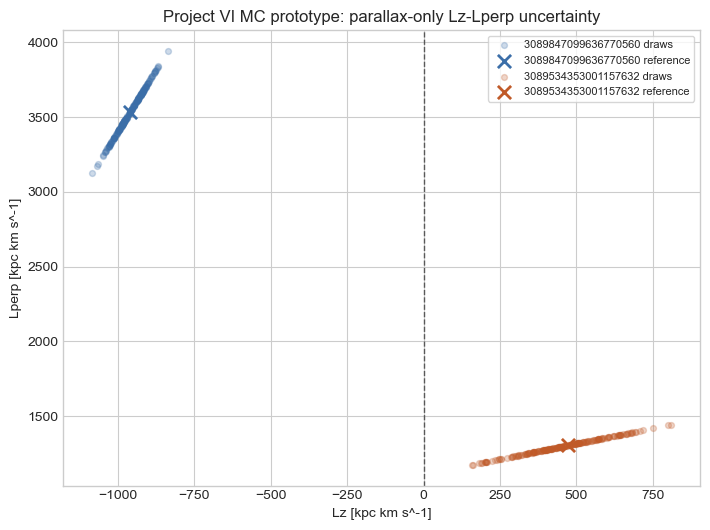

/Users/liors/Documents/research/gaia-lamost-galactic-archaeology/figures/project_vi_mc_prototype_lz_lperp_uncertainty.png


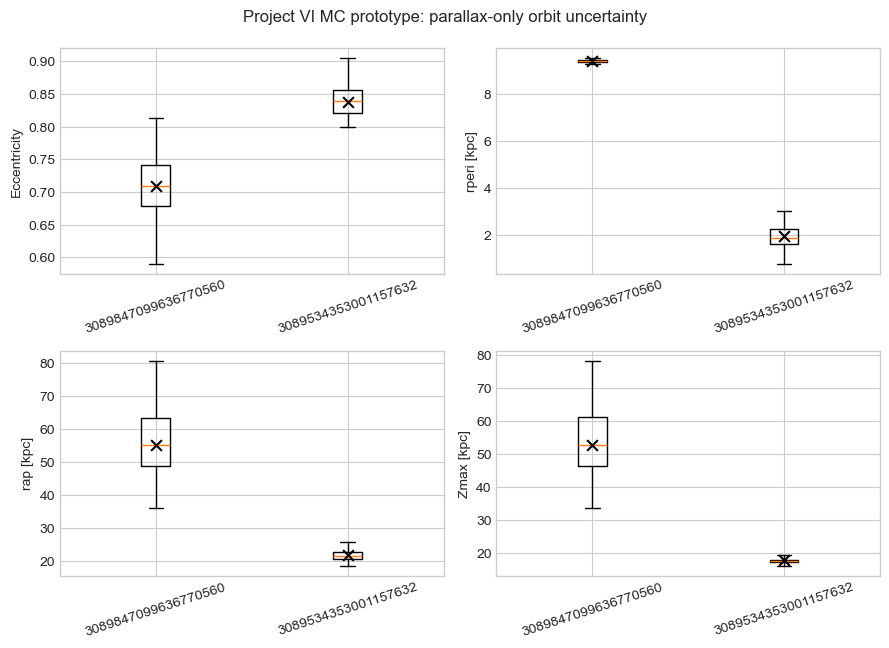

/Users/liors/Documents/research/gaia-lamost-galactic-archaeology/figures/project_vi_mc_prototype_orbit_uncertainty.png


In [7]:
fig, ax = plt.subplots(figsize=(7.2, 5.4))
colors = {TARGET_IDS[0]: "#3b6ea8", TARGET_IDS[1]: "#c05a28"}
for sid in TARGET_IDS:
    valid = draws[(draws["source_id"] == sid) & (draws["valid_draw"])]
    ref = candidate_summary[candidate_summary["source_id"] == sid].iloc[0]
    ax.scatter(valid["Lz_kpc_kms"], valid["Lperp_kpc_kms"], s=18, alpha=0.25, color=colors[sid], label=f"{sid} draws")
    ax.scatter(ref["Lz_reference"], ref["Lperp_reference"], s=90, marker="x", color=colors[sid], linewidth=2.0, label=f"{sid} reference")
ax.axvline(0, color="0.35", linestyle="--", linewidth=1)
ax.set_xlabel("Lz [kpc km s^-1]")
ax.set_ylabel("Lperp [kpc km s^-1]")
ax.set_title("Project VI MC prototype: parallax-only Lz-Lperp uncertainty")
ax.legend(fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(FIG_L, dpi=220)
plt.show()
print(FIG_L)

fig, axes = plt.subplots(2, 2, figsize=(9, 6.5))
plot_metrics = [("galpy_eccentricity", "Eccentricity"), ("galpy_rperi_kpc", "rperi [kpc]"), ("galpy_rap_kpc", "rap [kpc]"), ("galpy_zmax_kpc", "Zmax [kpc]")]
for ax, (metric, label) in zip(axes.ravel(), plot_metrics):
    data = [draws[(draws["source_id"] == sid) & (draws["valid_draw"])][metric].dropna().to_numpy() for sid in TARGET_IDS]
    ax.boxplot(data, labels=TARGET_IDS, showfliers=False)
    for i, sid in enumerate(TARGET_IDS, start=1):
        ref_col = {
            "galpy_eccentricity": "eccentricity_reference",
            "galpy_rperi_kpc": "rperi_reference",
            "galpy_rap_kpc": "rap_reference",
            "galpy_zmax_kpc": "Zmax_reference",
        }[metric]
        ref = candidate_summary[candidate_summary["source_id"] == sid].iloc[0][ref_col]
        ax.scatter(i, ref, color="black", marker="x", s=60, zorder=3)
    ax.set_ylabel(label)
    ax.tick_params(axis="x", labelrotation=18)
fig.suptitle("Project VI MC prototype: parallax-only orbit uncertainty", y=0.99)
fig.tight_layout()
fig.savefig(FIG_ORBIT, dpi=220)
plt.show()
print(FIG_ORBIT)

In [8]:
def fmt_triplet(row, short):
    return f"{row[f'{short}_mc_median']:.6g} [{row[f'{short}_mc_p16']:.6g}, {row[f'{short}_mc_p84']:.6g}]"

lines = [
    "# Project VI - Small-Scale Monte Carlo Uncertainty Propagation Prototype",
    "",
    "## Scope",
    "",
    "This report documents a small-scale Project VI Monte Carlo prototype for exactly two `validation_priority_A` candidates. It is not a full uncertainty budget and it is not full Gaia astrometric covariance propagation.",
    "",
    "The only enabled mode is `measured_only_parallax`. Parallax is sampled from the catalog central value using the measured-derived uncertainty `parallax / parallax_over_error`. RA, Dec, proper motion, and radial velocity are held fixed in every draw. Distance is recomputed from each sampled parallax and is not independently sampled.",
    "",
    "Assumed uncertainty is not used in this first prototype.",
    "",
    "## Inputs",
    "",
    "Input tables:",
    "",
    "- `data/processed/project_vi_validation_priority_candidates.csv`",
    "- `data/processed/gaia_lamost_larger_velocity_features.csv`",
    "- `data/processed/project_ii_galpy_orbit_candidates.csv`",
    "",
    "Prototype targets:",
    "",
]
for _, row in candidate_summary.iterrows():
    lines.append(f"- `{row.source_id}`: parallax={row.parallax:.6f} mas, parallax_error={row.parallax_error:.6f} mas, pmra={row.pmra:.6f} mas/yr, pmdec={row.pmdec:.6f} mas/yr, rv={row.radial_velocity:.2f} km/s.")

lines += [
    "",
    "## Uncertainty Provenance",
    "",
    "Measured-derived uncertainty:",
    "",
    "- Parallax uncertainty is derived from the measured Gaia parallax and `parallax_over_error`.",
    "",
    "Missing uncertainty:",
    "",
    "- `pmra_error` is missing for these two candidates in the current recovered tables.",
    "- `pmdec_error` is missing for these two candidates in the current recovered tables.",
    "- `radial_velocity_error` and LAMOST `rv_err` are missing for these two candidates in the current recovered tables.",
    "- Independent `distance_error` is missing; distance is derived from sampled parallax.",
    "- Astrometric covariance/correlation columns are missing for these two candidates and are not used.",
    "",
    "Assumed uncertainty:",
    "",
    "- Not used. No proper-motion or radial-velocity observational uncertainty is invented in this prototype.",
    "",
    "## Method",
    "",
    "Each candidate receives 200 parallax draws from a Gaussian distribution. Non-positive parallax draws are rejected and counted. For every valid draw, inverse parallax gives distance in kpc. The notebook then recomputes `Lz`, `Lperp`, `Ltot`, eccentricity, `rperi`, `rap`, and `Zmax` using the existing Project II conventions: Astropy Galactocentric coordinates for angular momentum, and `galpy` `Orbit(..., radec=True, ro=8.2, vo=232.0, solarmotion='schoenrich')` with `MWPotential2014`, 5 Gyr integration, and 1001 time steps for orbit quantities.",
    "",
    "## Results",
    "",
    "Values are reported as median [p16, p84].",
    "",
    "| source_id | success_fraction | Lz | Lperp | eccentricity | rperi_kpc | rap_kpc | Zmax_kpc |",
    "|:--|--:|--:|--:|--:|--:|--:|--:|",
]
for _, row in candidate_summary.iterrows():
    lines.append("| {source_id} | {success:.3f} | {Lz} | {Lperp} | {ecc} | {rperi} | {rap} | {zmax} |".format(
        source_id=row.source_id,
        success=row.success_fraction,
        Lz=fmt_triplet(row, "Lz"),
        Lperp=fmt_triplet(row, "Lperp"),
        ecc=fmt_triplet(row, "eccentricity"),
        rperi=fmt_triplet(row, "rperi"),
        rap=fmt_triplet(row, "rap"),
        zmax=fmt_triplet(row, "Zmax"),
    ))

lines += [
    "",
    "## Interpretation Boundary",
    "",
    "This prototype only answers whether the two high-priority candidates are stable to the available parallax uncertainty. It cannot validate robustness to the full observational error budget because proper-motion errors, radial-velocity errors, distance errors, and covariance/correlation terms are missing from the current inputs.",
    "",
    "The existing `distance_quality_flag` can read as `missing_parallax`, but the larger recovered tables do contain parallax central values for both prototype targets. The limiting issue here is missing full uncertainty/covariance propagation inputs, not absence of parallax central values.",
    "",
    "No claim of physical population validation is made from this prototype.",
    "",
    "## Outputs",
    "",
    "- `notebooks/31_project_vi_small_scale_mc_uncertainty_propagation.ipynb`",
    "- `data/processed/project_vi_mc_prototype_candidate_uncertainties.csv`",
    "- `data/processed/project_vi_mc_prototype_draw_summary.csv`",
    "- `figures/project_vi_mc_prototype_orbit_uncertainty.png`",
    "- `figures/project_vi_mc_prototype_lz_lperp_uncertainty.png`",
]

OUT_REPORT.write_text("\n".join(lines) + "\n")
print("Saved", OUT_REPORT)

Saved /Users/liors/Documents/research/gaia-lamost-galactic-archaeology/report/project_vi_small_scale_mc_uncertainty_prototype.md
